In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Cài đặt style chung cho Seaborn
sns.set_theme(style="whitegrid")

# 1. Tải dữ liệu trực tiếp từ Our World in Data (có thể mất 1-2 phút)
url = 'https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv'
print("Đang tải dữ liệu...")
df_raw = pd.read_csv(url)

# 2. Lọc dữ liệu khu vực Đông Nam Á & Giới hạn thời gian (2021 - 2022)
asean_countries = ['Vietnam', 'Thailand', 'Indonesia', 'Malaysia', 'Singapore', 'Philippines']
df = df_raw[df_raw['location'].isin(asean_countries)].copy()

df['date'] = pd.to_datetime(df['date'])
df = df[(df['date'] >= '2021-01-01') & (df['date'] <= '2022-12-31')]

# 3. Lọc ra các cột quan trọng cần thiết cho bài tập
cols_to_keep = [
    'location', 'date', 'new_cases', 'new_deaths',
    'new_tests', 'total_vaccinations', 'people_fully_vaccinated_per_hundred'
]
df = df[cols_to_keep]

# 4. Xử lý NaN cơ bản (Điền 0 cho ca mắc/tử vong/test mới; fill forward cho vaccine vì là số liệu tích lũy)
df[['new_cases', 'new_deaths', 'new_tests']] = df[['new_cases', 'new_deaths', 'new_tests']].fillna(0)
df['total_vaccinations'] = df.groupby('location')['total_vaccinations'].ffill().fillna(0)
df['people_fully_vaccinated_per_hundred'] = df.groupby('location')['people_fully_vaccinated_per_hundred'].ffill().fillna(0)

print(df.head())

Đang tải dữ liệu...
         location       date  new_cases  new_deaths  new_tests  \
175593  Indonesia 2021-01-01        0.0         0.0        0.0   
175594  Indonesia 2021-01-02        0.0         0.0        0.0   
175595  Indonesia 2021-01-03    51985.0      1497.0        0.0   
175596  Indonesia 2021-01-04        0.0         0.0        0.0   
175597  Indonesia 2021-01-05        0.0         0.0        0.0   

        total_vaccinations  people_fully_vaccinated_per_hundred  
175593                 0.0                                  0.0  
175594                 0.0                                  0.0  
175595                 0.0                                  0.0  
175596                 0.0                                  0.0  
175597                 0.0                                  0.0  


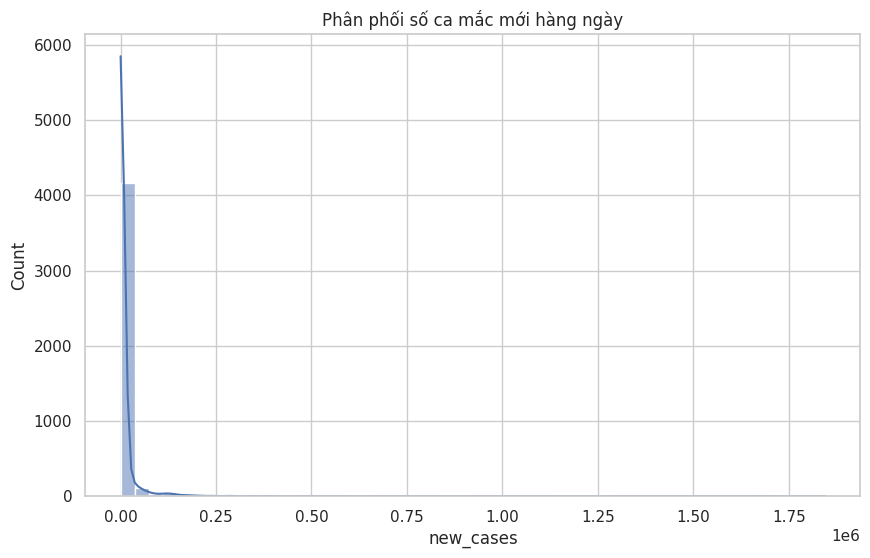

In [3]:
# Câu 1: Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['new_cases'], bins=50, kde=True)
plt.title('Phân phối số ca mắc mới hàng ngày')
plt.show()

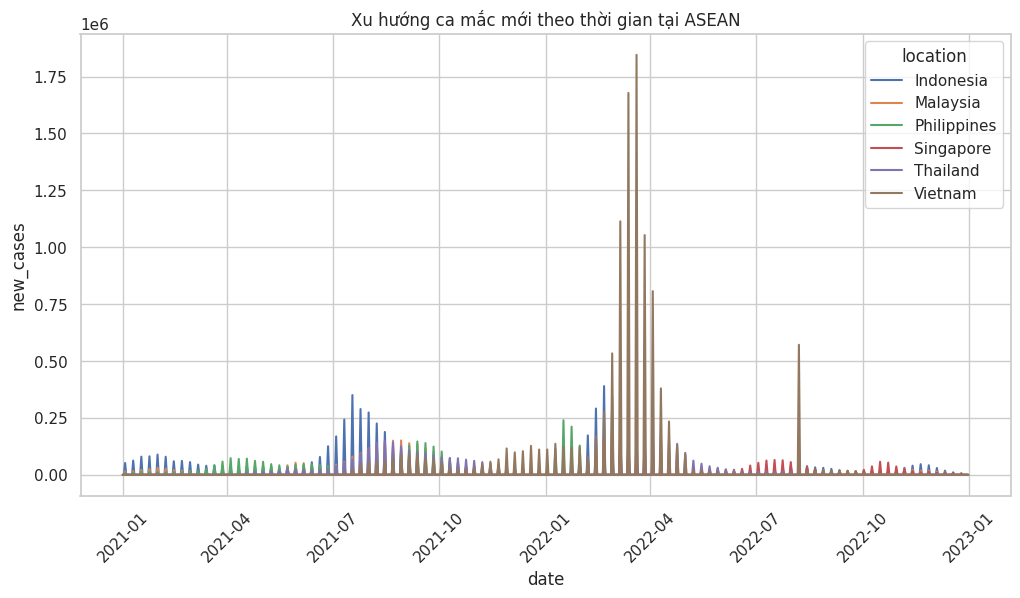

In [4]:
# Câu 2: Line Chart
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='date', y='new_cases', hue='location')
plt.title('Xu hướng ca mắc mới theo thời gian tại ASEAN')
plt.xticks(rotation=45)
plt.show()

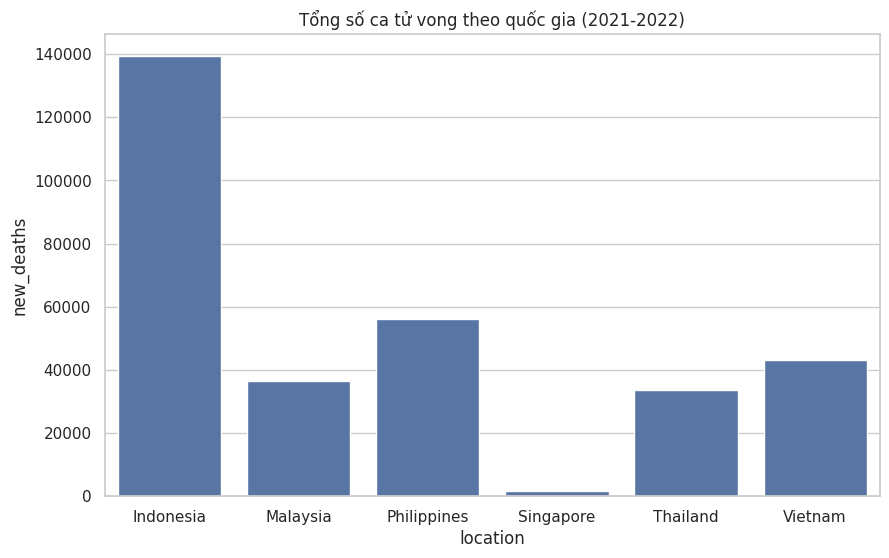

In [5]:
# Câu 3: Bar Chart
death_summary = df.groupby('location')['new_deaths'].sum().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=death_summary, x='location', y='new_deaths')
plt.title('Tổng số ca tử vong theo quốc gia (2021-2022)')
plt.show()

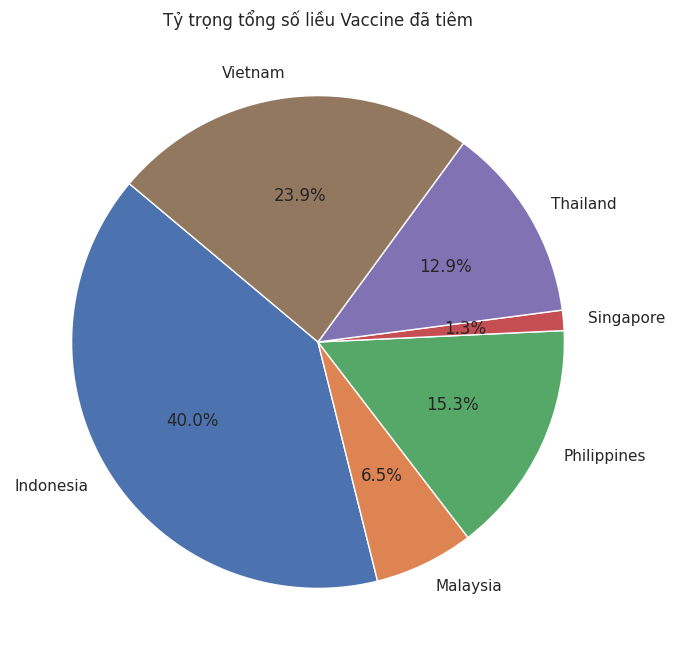

In [6]:
# Câu 4: Pie Chart
vaccine_max = df.groupby('location')['total_vaccinations'].max()
plt.figure(figsize=(8, 8))
plt.pie(vaccine_max, labels=vaccine_max.index, autopct='%1.1f%%', startangle=140)
plt.title('Tỷ trọng tổng số liều Vaccine đã tiêm')
plt.show()

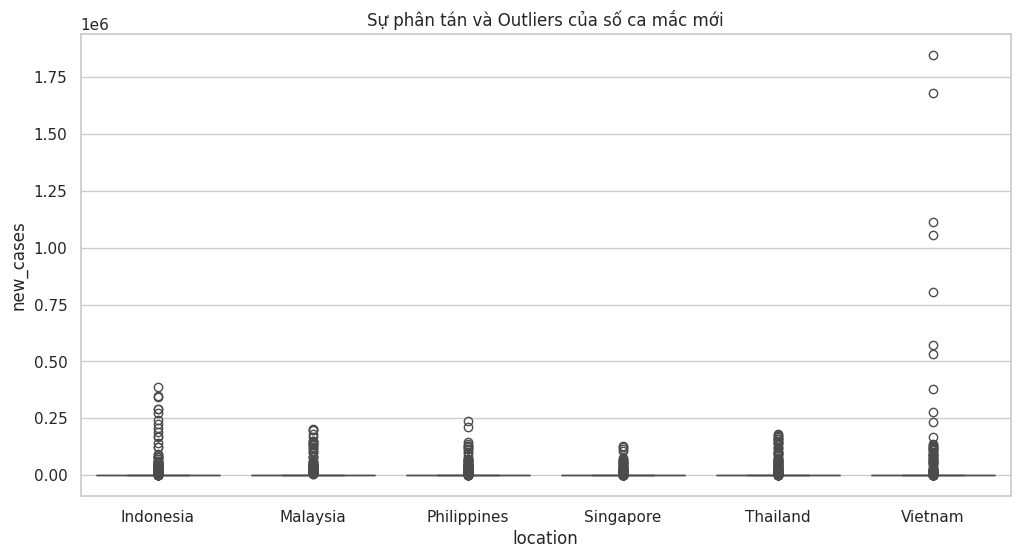

In [7]:
# Câu 5: Box Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='location', y='new_cases')
plt.title('Sự phân tán và Outliers của số ca mắc mới')
plt.show()

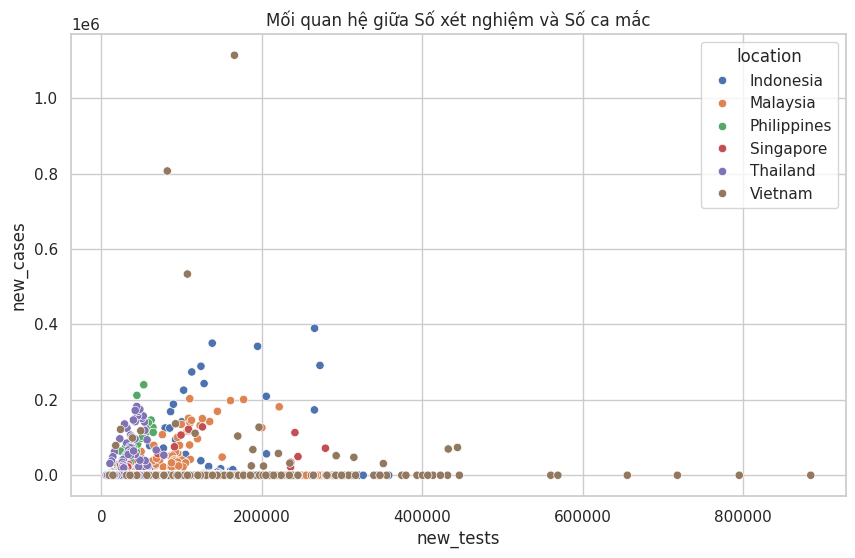

In [8]:
# Câu 6: Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['new_tests'] > 0], x='new_tests', y='new_cases', hue='location')
plt.title('Mối quan hệ giữa Số xét nghiệm và Số ca mắc')
plt.show()

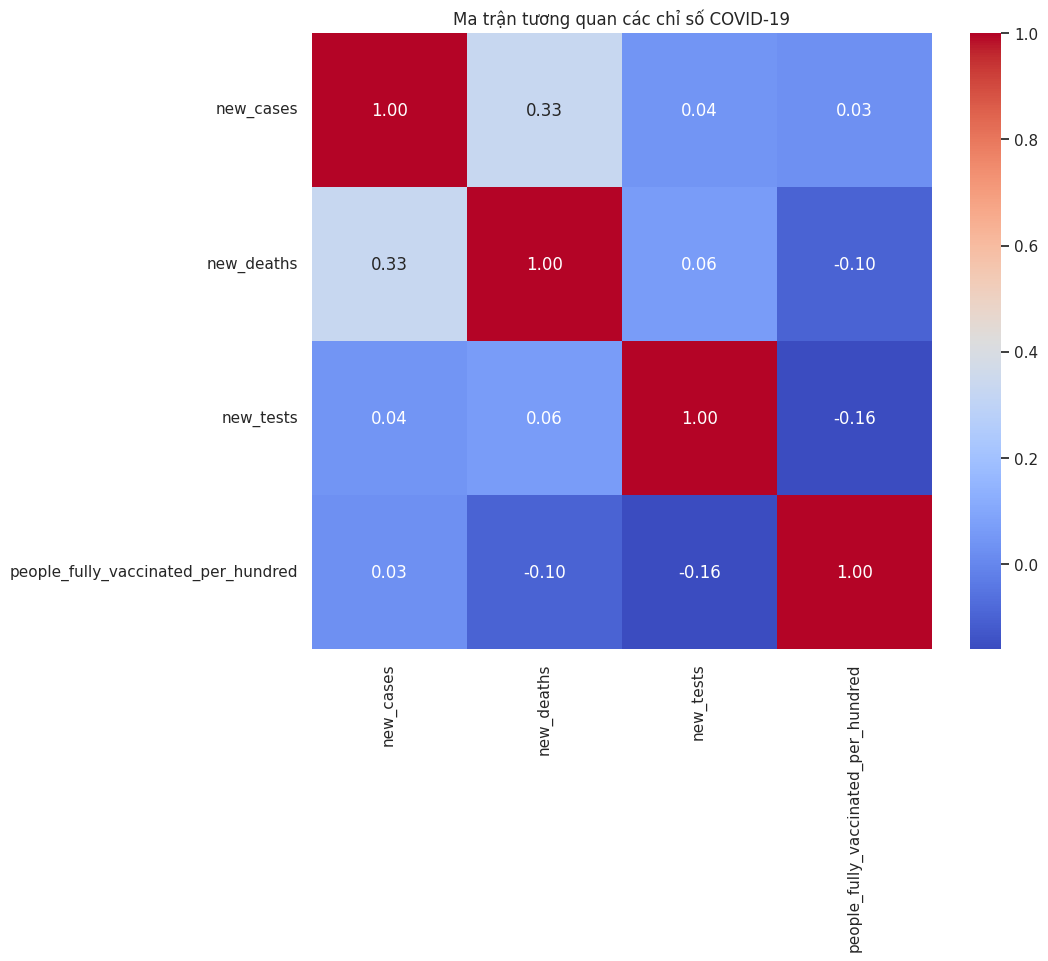

In [9]:
# Câu 7: Heatmap
corr_matrix = df[['new_cases', 'new_deaths', 'new_tests', 'people_fully_vaccinated_per_hundred']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận tương quan các chỉ số COVID-19')
plt.show()

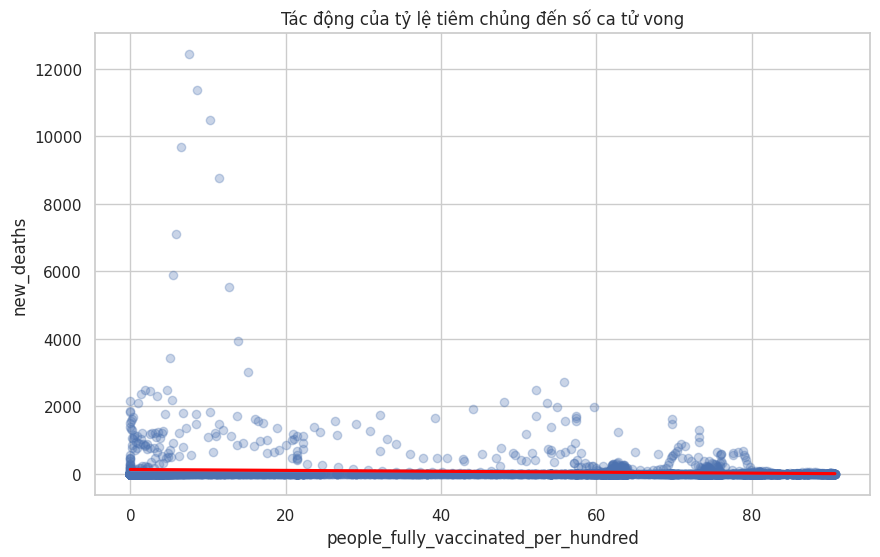

In [10]:
# Câu 8: Regression Plot
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='people_fully_vaccinated_per_hundred', y='new_deaths',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Tác động của tỷ lệ tiêm chủng đến số ca tử vong')
plt.show()